In [126]:
#Import statments
# Uday Lingampalli
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from pandas.tseries.offsets import DateOffset
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, r2_score

In [92]:
#uploading the dataframe

df1 = pd.read_csv('content/idx_cleaned_data1.csv')
df2 = pd.read_csv('content/idx_cleaned_data2.csv')
df3 = pd.read_csv('content/idx_cleaned_data3.csv')

/var/folders/8_/6hpk2y3x57s3wdv38bd9rprm0000gn/T/ipykernel_2507/1075393482.py:4: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('content/idx_cleaned_data2.csv')
/var/folders/8_/6hpk2y3x57s3wdv38bd9rprm0000gn/T/ipykernel_2507/1075393482.py:5: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  df3 = pd.read_csv('content/idx_cleaned_data3.csv')


In [125]:
def mape(actual, predicted):
    n = len(actual)
    total = 0.0
    for a, p in zip(actual, predicted):
        total += abs((a - p) / a)
    return (total / n) * 100

def mdape(actual, predicted):
    percentage_errors = []
    for a, p in zip(actual, predicted):
        percentage_errors.append(abs((a - p) / a) * 100)
    return np.median(percentage_errors)

In [93]:
df = pd.merge(df1, df2, how = 'outer')
df = pd.merge(df, df3, how='outer')

In [94]:
#removing any potential outliers within the ClosePrice variable

Q1 = df['ClosePrice'].quantile(0.005)
Q3 = df['ClosePrice'].quantile(0.995)


df = df[(df['ClosePrice'] >= Q1) & (df['ClosePrice'] <= Q3)]

In [95]:
#Creating the train/test split

df['CloseDate'] = pd.to_datetime(df['CloseDate'], yearfirst=True);

last_date = df['CloseDate'].max();
test_date = last_date-DateOffset(months=1);
train_date = test_date-DateOffset(months=6);

train_df = df[(df['CloseDate'] > train_date) & (df['CloseDate'] < test_date)];
test_df = df[(df['CloseDate'] >= test_date)];
test_df = test_df[(test_df['ClosePrice'] > test_df['ClosePrice'].quantile(0.05)) & (test_df['ClosePrice'] < test_df['ClosePrice'].quantile(0.95))]

train_y = train_df['ClosePrice'];
test_y = test_df['ClosePrice'];

In [96]:
#Dropping some colums to improve the df
drop_cols = ['Flooring', 'Levels', 'UnparsedAddress', 'PostalCode', 'City', 'StreetNumberNumeric', 'PropertyType', 'PropertySubType', 'ClosePrice', 'CloseDate', 'DaysOnMarket', 'BuyerOfficeName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'BuyerAgentAOR', 'BuyerOfficeAOR', 'ContractStatusChangeDate', 'PurchaseContractDate', 'MLSAreaMajor', 'CountyOrParish', 'ElementarySchool', 'SubdivisionName', 'ListingContractDate', 'HighSchool', 'HighSchoolDistrict', 'StateOrProvince', 'MiddleOrJuniorSchool'];
train_X = train_df.drop(columns=drop_cols);
test_X = test_df.drop(columns=drop_cols);
#Uday Lingampalli

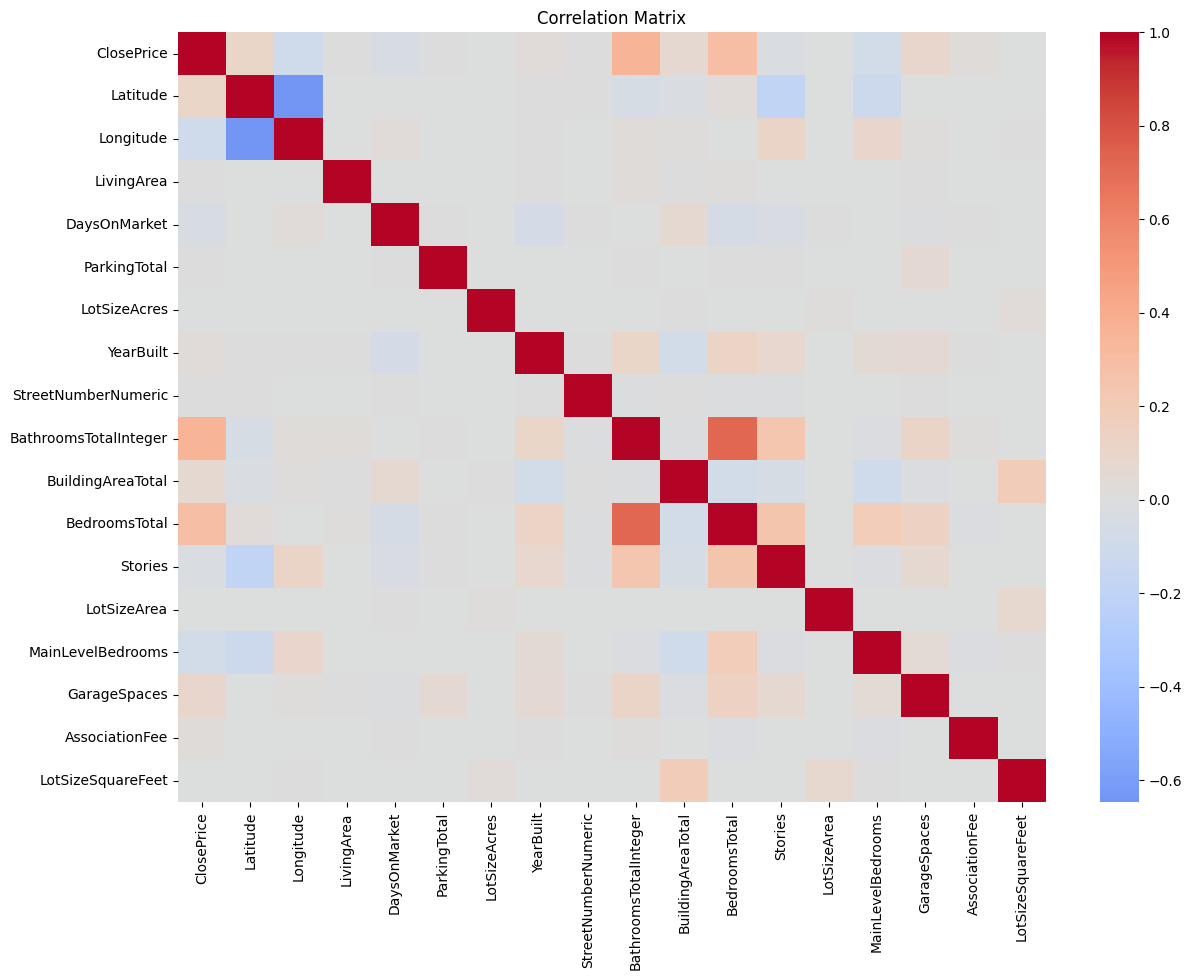

In [97]:
#Building the correlation matrix
#Oumar Sow
corr_matrix = df.select_dtypes(include='number').corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [98]:
#Creating a function to complete forward selection on the dataframe

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

def forward_selection(df, target_col, metric='r2', cv=5):
    X = df.drop(columns=[target_col])
    y = df[target_col]

    X = pd.get_dummies(X, drop_first=True)

    remaining = list(X.columns)
    selected = []
    results = []
    best_overall_score = -np.inf

    model = LinearRegression()

    for step in range(len(remaining)):
        best_score = -np.inf
        best_feature = None

        for feature in remaining:
            candidate = selected + [feature]
            cv_scores = cross_val_score(
                model, X[candidate], y,
                cv=cv, scoring='r2'
            )
            score = cv_scores.mean()

            if score > best_score:
                best_score = score
                best_feature = feature

        if best_score <= best_overall_score:
            print(f"Stopping early at step {step+1} — no improvement found.")
            break

        selected.append(best_feature)
        remaining.remove(best_feature)
        best_overall_score = best_score

        results.append({
            'step': step + 1,
            'feature_added': best_feature,
            'cv_r2': round(best_score, 4),
            'features_so_far': selected.copy()
        })

        print(f"Step {step+1}: Added '{best_feature}' | CV R² = {best_score:.4f}")

    results_df = pd.DataFrame(results)
    return selected, results_df

In [99]:
#Using numeric colums due to issues using the model with categorical columns
num_cols = train_df.select_dtypes(include='number').columns
num_cols = num_cols.drop(['DaysOnMarket'])
nf_train_df = train_df
train_df = train_df[num_cols]

In [100]:
#Setting the x and y for the model

X = train_df.drop(columns=['ClosePrice'])
y = train_df['ClosePrice']

In [128]:
#Running the forward selection function on the training data
selected_features, results_df = forward_selection(train_df, target_col='ClosePrice')

final_df = selected_features
model = LinearRegression()
model.fit(train_X[selected_features], train_y)
print("Final 5 features:", final_df)
print(f"R²: {r2_score(test_y, model.predict(test_X[selected_features])):.4f}")
print(f"MAPE: {mape(test_y, model.predict(test_X[selected_features])):.4f}")
print(f"MdAPE: {mdape(test_y, model.predict(test_X[selected_features])):.4f}")

Step 1: Added 'BathroomsTotalInteger' | CV R² = 0.0899
Step 2: Added 'Longitude' | CV R² = 0.0966
Step 3: Added 'MainLevelBedrooms' | CV R² = 0.1000
Step 4: Added 'BedroomsTotal' | CV R² = 0.1050
Step 5: Added 'Stories' | CV R² = 0.1103
Step 6: Added 'GarageSpaces' | CV R² = 0.1113
Stopping early at step 7 — no improvement found.
Final 5 features: ['BathroomsTotalInteger', 'Longitude', 'MainLevelBedrooms', 'BedroomsTotal', 'Stories', 'GarageSpaces']
R²: -0.1175
MAPE: 4130.3248
MdAPE: 43.3800


In [ ]:


X_train = train_df.drop(columns = ['ClosePrice'])
X_train = train_df[num_cols].drop(columns=['ClosePrice'])
y_train = train_df['ClosePrice']

tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)


# Evaluate
y_test = test_df['ClosePrice']
y_pred = tree.predict(test_df[num_cols].drop(columns=['ClosePrice']))

print(f"R²: {r2_score(y_train, tree.predict(X_train)):.4f}")
print(f"R²: {r2_score(y_test, y_pred):.4f}")
#print(f"RMSE: {mean_squared_error(y_test, y_pred, squared=False):.4f}")
#Oumar

R²: 0.9987
R²: -0.3353


In [103]:
#Uday Lingampalli
#Don't get ppsf feature, aren't we predicting Close Price?
nf_train_df['bbratio'] = (nf_train_df['BathroomsTotalInteger']/nf_train_df['BedroomsTotal'].replace(0, 1)).fillna(0)
nf_train_df['age'] = pd.to_datetime(nf_train_df['ContractStatusChangeDate']).dt.year-nf_train_df['YearBuilt']
test_df['bbratio'] = (test_df['BathroomsTotalInteger']/test_df['BedroomsTotal'].replace(0, 1)).fillna(0)
test_df['age'] = pd.to_datetime(test_df['ContractStatusChangeDate']).dt.year-test_df['YearBuilt']

/var/folders/8_/6hpk2y3x57s3wdv38bd9rprm0000gn/T/ipykernel_2507/3009456238.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nf_train_df['bbratio'] = (nf_train_df['BathroomsTotalInteger']/nf_train_df['BedroomsTotal'].replace(0, 1)).fillna(0)
/var/folders/8_/6hpk2y3x57s3wdv38bd9rprm0000gn/T/ipykernel_2507/3009456238.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nf_train_df['age'] = pd.to_datetime(nf_train_df['ContractStatusChangeDate']).dt.year-nf_train_df['YearBuilt']


In [104]:
num_cols = nf_train_df.select_dtypes(include='number').columns
nf_train_df = nf_train_df[num_cols]
X = nf_train_df.drop(columns=['ClosePrice'])
y = nf_train_df['ClosePrice']
selected_features, results_df = forward_selection(nf_train_df, target_col='ClosePrice')
final_df = selected_features
print("Final 5 features:", final_df)
X_train = nf_train_df[num_cols]
y_train = nf_train_df['ClosePrice']

tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)


# Evaluate
y_test = test_df['ClosePrice']
y_pred = tree.predict(test_df[num_cols])

print(f"R²: {r2_score(y_test, y_pred):.4f}")

Step 1: Added 'BathroomsTotalInteger' | CV R² = 0.0899
Step 2: Added 'bbratio' | CV R² = 0.1221
Step 3: Added 'MainLevelBedrooms' | CV R² = 0.1361
Step 4: Added 'Longitude' | CV R² = 0.1422
Step 5: Added 'Stories' | CV R² = 0.1487
Step 6: Added 'DaysOnMarket' | CV R² = 0.1503
Step 7: Added 'BedroomsTotal' | CV R² = 0.1525
Step 8: Added 'GarageSpaces' | CV R² = 0.1530
Stopping early at step 9 — no improvement found.
Final 5 features: ['BathroomsTotalInteger', 'bbratio', 'MainLevelBedrooms', 'Longitude', 'Stories', 'DaysOnMarket', 'BedroomsTotal', 'GarageSpaces']
R²: 1.0000


In [105]:
X_train_rf = nf_train_df.drop(columns=['ClosePrice'])
y_train_rf = nf_train_df['ClosePrice']

X_test_rf = test_df[num_cols].drop(columns=['ClosePrice'])
y_test_rf = test_df['ClosePrice']

In [106]:
rf_param_grid = {
    'n_estimators':      [25, 50, 75],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5, 10],
}

rf_grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    scoring='r2',
    cv=5,
    verbose=2,
    n_jobs=-1
)

rf_grid_search.fit(X_train_rf, y_train_rf)

print("\nBest parameters:", rf_grid_search.best_params_)
print(f"Best CV R²:       {rf_grid_search.best_score_:.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END max_depth=None, min_samples_split=2, n_estimators=25; total time=  20.8s
[CV] END max_depth=None, min_samples_split=2, n_estimators=25; total time=  20.9s
[CV] END max_depth=None, min_samples_split=2, n_estimators=25; total time=  21.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=25; total time=  21.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=25; total time=  21.4s
[CV] END max_depth=None, min_samples_split=2, n_estimators=50; total time=  35.8s
[CV] END max_depth=None, min_samples_split=2, n_estimators=50; total time=  36.0s
[CV] END max_depth=None, min_samples_split=2, n_estimators=50; total time=  35.6s
[CV] END max_depth=None, min_samples_split=2, n_estimators=50; total time=  36.7s
[CV] END max_depth=None, min_samples_split=2, n_estimators=50; total time=  36.8s
[CV] END max_depth=None, min_samples_split=5, n_estimators=25; total time=  19.1s
[CV] END max_depth=None, min_samples

In [ ]:
best_rf   = rf_grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test_rf)

print(f"Test R²:   {r2_score(y_test_rf, y_pred_rf):.4f}")
print(f"MAPE: {mape(y_test_rf, y_pred_rf)}")
print(f"MdAPE: {mdape(y_test_rf, y_pred_rf)}")
#Uday Lingampalli

Test R²:   0.4132
MAPE: 1884.831274263654
MdAPE: 17.429942618675017


In [135]:
X_test_rf.columns

Index(['Latitude', 'Longitude', 'LivingArea', 'DaysOnMarket', 'ParkingTotal',
       'LotSizeAcres', 'YearBuilt', 'StreetNumberNumeric',
       'BathroomsTotalInteger', 'BuildingAreaTotal', 'BedroomsTotal',
       'Stories', 'LotSizeArea', 'MainLevelBedrooms', 'GarageSpaces',
       'AssociationFee', 'LotSizeSquareFeet', 'bbratio', 'age'],
      dtype='object')

/var/folders/8_/6hpk2y3x57s3wdv38bd9rprm0000gn/T/ipykernel_2507/393602640.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data, x='Model', y='Test MdAPE', palette=['lightgrey', 'orange', 'darkturquoise'])


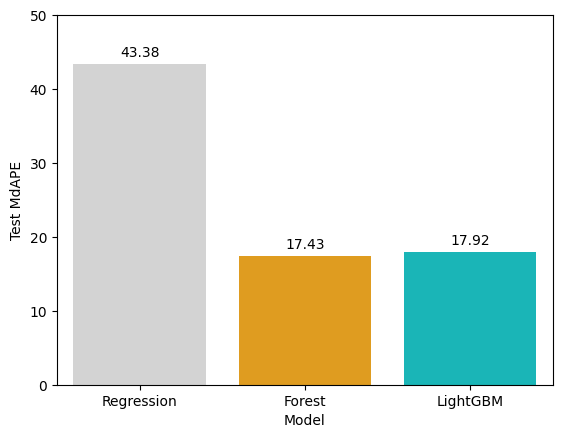

In [134]:
data = {
    'Model': ['Regression', 'Forest', 'LightGBM'],
    'Test R^2': [-0.1175, 0.4132, 0.8215],
    'Test MAPE': [4130.32, 1884.83, 543.79],
    'Test MdAPE': [43.38, 17.43, 17.92]
}
import seaborn as sns
ax = sns.barplot(data, x='Model', y='Test MdAPE', palette=['lightgrey', 'orange', 'darkturquoise'])
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.ylim(0, 50)
plt.show()